In [ ]:
import xarray as xr
import sys
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import datetime as dt
import seaborn as sns

sys.path.append("../src/helpers")
from analysis_helpers import combine_state_features

# Define prediction datasets to compare
prediction_datasets = {
    "Baseline": "../evals/baseline_unroll30.zarr",
    # "Baseline + rr": "../evals/rain_unroll30.zarr",
    # # "Baseline + rr": "../evals/rain_mse_boxcox_unroll100.zarr",
    # "Baseline + qv": "../evals/qv_unroll30.zarr",
    # "Baseline + fluxes": "../evals/lhfl_unroll30.zarr",
    # "Baseline + lw": "../evals/lw_unroll30.zarr",
    # "Baseline + sw": "../evals/sw_unroll30.zarr",
    # "Baseline + swlw": "../evals/swlw_unroll30.zarr",
    # # "Baseline + BT": "../evals/rain_mse_boxcox2.zarr",
    # "Surface only": "../evals/sfconly_unroll30.zarr",
    # "Bare-minimum": "../evals/bare-minimum_unroll30.zarr",
}

# Load predictions
predictions = {
    name: combine_state_features(xr.open_dataset(path, engine="zarr", chunks="auto"))
    for name, path in prediction_datasets.items()
}
ground_truth = xr.open_dataset("../data/experiment/data/datastore.interior.domain03.zarr", engine="zarr")
combined_ground_truth = combine_state_features(ground_truth)

In [61]:
start_time = dt.datetime.strptime("2020-02-16T00:00:00", "%Y-%m-%dT%H:%M:%S")
elapsed_forecast_duration=dt.timedelta(minutes=300)
pred = predictions['Baseline']['t_2m'].sel(start_time=start_time, elapsed_forecast_duration=elapsed_forecast_duration)
pred_cdf = norm.cdf(pred, loc=pred.mean(), scale=pred.std())

In [62]:
ref = combined_ground_truth['t_2m'].sel(time=start_time + elapsed_forecast_duration)
ref_cdf = norm.cdf(ref, loc=ref.mean(), scale=ref.std())

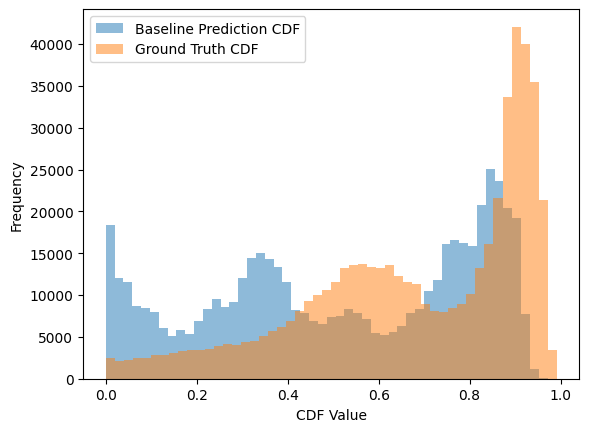

In [63]:
plt.hist(pred_cdf, bins=50, alpha=0.5, label='Baseline Prediction CDF')
plt.hist(ref_cdf, bins=50, alpha=0.5, label='Ground Truth CDF')
plt.xlabel('CDF Value')
plt.ylabel('Frequency')
plt.legend()

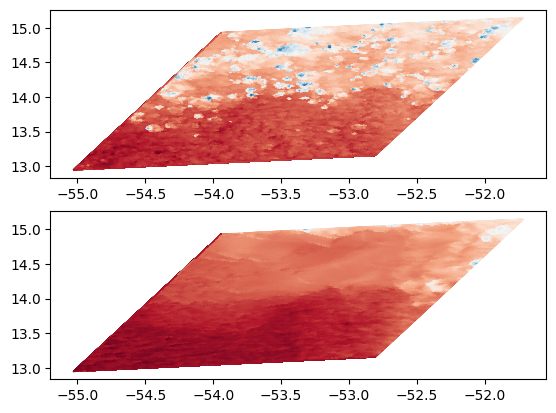

In [25]:
fig, axes = plt.subplots(2,1)

lons = np.rad2deg(ref.clon)
lats = np.rad2deg(ref.clat)

axes.flatten()[0].tripcolor(
    lons,
    lats,
    ref,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=ref.min(),
    vmax=ref.max(),
)

axes.flatten()[1].tripcolor(
    lons,
    lats,
    pred,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=ref.min(),
    vmax=ref.max(),
)
plt.show()

In [26]:
plt.close('all')

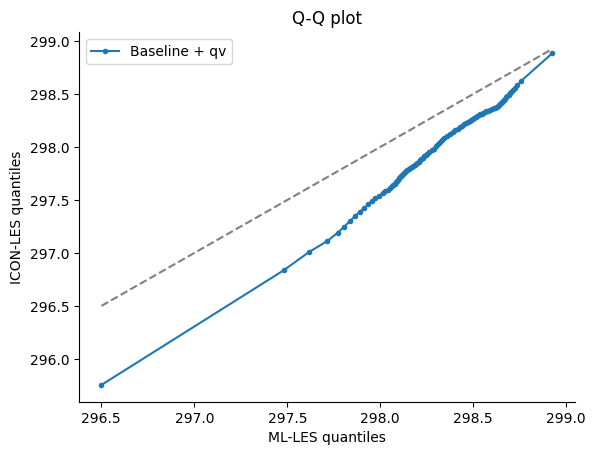

In [41]:
# compute quantiles for q-q plot
quantiles = np.linspace(0, 1, 101)
pred_q = np.quantile(pred.values.flatten(), quantiles)
ref_q = np.quantile(ref.values.flatten(), quantiles)

plt.figure()
plt.plot(pred_q, ref_q, marker='.', linestyle='-', label='Baseline + qv')
plt.plot([pred_q.min(), pred_q.max()], [pred_q.min(), pred_q.max()], color='grey', linestyle='--', label=None)
plt.xlabel('ML-LES quantiles')
plt.ylabel('ICON-LES quantiles')
plt.legend()
plt.title('Q-Q plot')
sns.despine()


## Use full set of predictions by using outut from compuate_all_metrics.sh

In [1]:
import xarray as xr
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
dss = []
for exp in ["baseline", "sfconly", "qv", "sw", "lw", "swlw", "rr", "bare_minimum"]:
    ds = xr.open_dataset(f"percentiles_{exp}.nc")
    ds = ds.assign(exp=exp)
    dss.append(ds)

In [21]:
ds_pred = xr.concat(dss, dim="source")

/tmp/ipykernel_2623525/206766143.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'start_time' ('start_time',) The recommendation is to set join explicitly for this case.
  ds_pred = xr.concat(dss, dim="source")
/tmp/ipykernel_2623525/206766143.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_pred = xr.concat(dss, dim="source")
/tmp/ipykernel_2623525/206766143.py:1: FutureWarning: In a future version of

In [24]:
# Count NaN values in t_2m for each source
nan_counts = {}
for source in ds_pred.source.values:
    t2m = ds_pred['t_2m'].sel(source=source)
    nan_count = np.isnan(t2m.values).sum()
    nan_counts[source] = nan_count
nan_counts

{'Baseline': 0,
 'Sfconly': 0,
 'qv': 0,
 'sw': 0,
 'lw': 0,
 'swlw': 45450,
 'rr': 0,
 'bare-minimum': 0}

In [4]:
ds_gt = xr.open_dataset("percentiles_iconles.nc")

In [56]:
leadtime = np.timedelta64(300, "m")

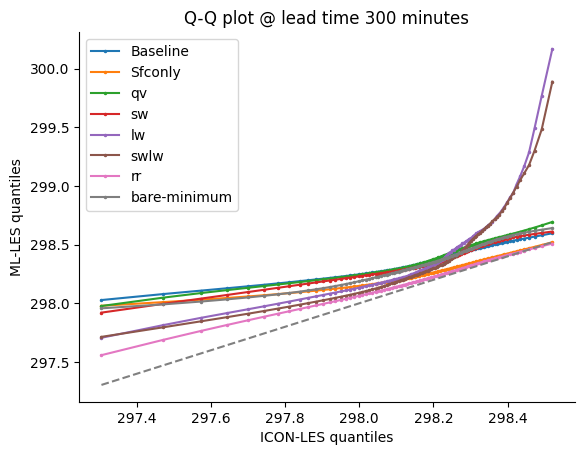

In [57]:
avg_q_gt = ds_gt.sel(source='ground_truth', variable='t_2m', time=ds_pred.start_time.values + leadtime)['t_2m'].mean(dim='time')

plt.figure()

q_to_plot = ds_pred.percentile.values[1:-1]

for source in ds_pred.source.values:
    avg_q_pred = ds_pred.sel(source=source, variable='t_2m', elapsed_forecast_duration=leadtime)['t_2m'].mean(dim='start_time')
    plt.plot(avg_q_gt.sel(percentile=q_to_plot), avg_q_pred.sel(percentile=q_to_plot), marker='.', linestyle='-', label=source, markersize=3)
plt.plot([avg_q_gt.sel(percentile=q_to_plot).min(), avg_q_gt.sel(percentile=q_to_plot).max()], [avg_q_gt.sel(percentile=q_to_plot).min(), avg_q_gt.sel(percentile=q_to_plot).max()], color='grey', linestyle='--', label=None)
plt.ylabel('ML-LES quantiles')
plt.xlabel('ICON-LES quantiles')
plt.legend()
plt.title(f'Q-Q plot @ lead time {leadtime}')
sns.despine()

# Comparison of distributions for a specific forecast time and lead time

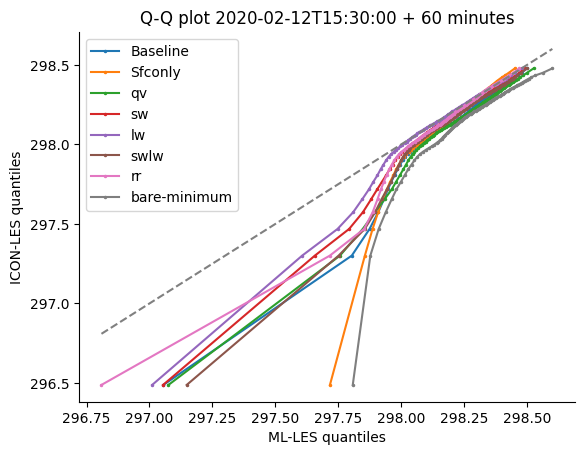

In [60]:
# ds_pred and ds_gt already contain the percentile information
# we can use them directly for distribution comparisons without
# reloading the full prediction datasets.

# example: pick a specific start time and lead and variable
start_time = np.datetime64("2020-02-12T15:30:00")
lead = np.timedelta64(60, "m")
var = "t_2m"

# select from the percentile datasets, then reconstruct a sample
# by inverting the CDF if desired or just plot percentiles directly
pred_sel = ds_pred[var].sel(start_time=start_time, elapsed_forecast_duration=lead, variable=var)
ref_sel = ds_gt[var].sel(source="ground_truth", variable=var, time=start_time + lead)

plt.figure()

q_to_plot = ds_pred.percentile.values[0:-1]

for source in ds_pred.source.values:
    avg_q_pred = pred_sel
    plt.plot(pred_sel.sel(percentile=q_to_plot, source=source), ref_sel.sel(percentile=q_to_plot), marker='.', linestyle='-', label=source, markersize=3)
plt.plot([pred_sel.sel(percentile=q_to_plot).min(), pred_sel.sel(percentile=q_to_plot).max()], [pred_sel.sel(percentile=q_to_plot).min(), pred_sel.sel(percentile=q_to_plot).max()], color='grey', linestyle='--', label=None)
plt.xlabel('ML-LES quantiles')
plt.ylabel('ICON-LES quantiles')
plt.legend()
plt.title(f'Q-Q plot {start_time} + {lead}')
sns.despine()